<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Link :- https://colab.research.google.com/drive/1ZF510YQmKkfyN2W8MaLpTVo-3yRPmr2b#scrollTo=oJhjqnVbvSJO

# Experiment 9: Isolation Forest — Anomaly Detection in Biological Data

---

##  Aim
To apply the **Isolation Forest** algorithm for anomaly detection on:
1. **Gene Expression Data** — identify abnormal gene activity patterns (potential biomarkers or diseased cells)
2. **Biological Cell Image Data** — detect anomalous cells (nuclei) in microscopy images

---

##  Theory

### What is Anomaly Detection?

**Anomaly Detection** (also called Outlier Detection) is the task of identifying data points that are **significantly different from the majority** of the data.

In biology:
- A **cancerous cell** behaves differently from normal cells
- A **mutated gene** has abnormal expression levels
- An **infected nucleus** has irregular shape or texture compared to healthy ones

Traditional methods (like distance-based or density-based outlier detection) struggle with **high-dimensional biological data**. Isolation Forest solves this.

---

### What is Isolation Forest?

**Isolation Forest** (Liu et al., 2008) is an unsupervised anomaly detection algorithm based on **Decision Trees**.

#### Core Idea:
> Anomalies are **rare** and **different** — they are easier to isolate than normal points.

#### How it works:
1. **Randomly select a feature** from the dataset
2. **Randomly select a split value** between the min and max of that feature
3. Split the data — keep doing this recursively until a point is isolated
4. **Anomalies** get isolated in **fewer splits** (short path length)
5. **Normal points** require **more splits** to isolate (long path length)

```
Normal point:          Anomaly point:
Many splits needed     Few splits needed
     |                      |
   __|__                   _|_
  |     |                 |   |
 _|_   _|_               *   |
|   | |   |         (isolated) |
...  ...  ...                 ...
```

---

### Anomaly Score

The **anomaly score** $s(x, n)$ is computed from the average path length:

$$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$

Where:
- $h(x)$ = path length for point $x$ (number of splits to isolate it)
- $c(n)$ = average path length of an unsuccessful BST search (normalizer)
- $E(h(x))$ = average path length over all trees

**Interpretation:**
- Score **close to 1** → anomaly (isolated quickly)
- Score **close to 0.5** → normal point
- Score **below 0.5** → definitely normal

---

### Why Isolation Forest for Biological Data?

| Property | Why it matters in Biology |
|----------|---------------------------|
| Works without labels | Biological anomalies are often unknown/unlabeled |
| Handles high dimensions | Gene expression data has thousands of genes |
| Fast | Can handle large genomics datasets |
| Unsupervised | No need for pre-annotated disease samples |

---

### Applications in Biology
- **Genomics**: Detecting abnormal gene expression (cancer biomarkers)
- **Cell biology**: Finding abnormal nuclei in microscopy images
- **Drug discovery**: Identifying anomalous drug responses
- **Proteomics**: Detecting unusual protein expression patterns
- **Evolution**: Identifying genes with unusual mutation patterns

---

### Key Parameters

| Parameter | Meaning | Default |
|-----------|---------|--------|
| `n_estimators` | Number of isolation trees | 100 |
| `contamination` | Expected proportion of anomalies | 'auto' |
| `max_samples` | Samples per tree (subsampling) | 'auto' |
| `max_features` | Features per tree | 1.0 |

---

## Step 1: Install and Import Libraries

In [ ]:
# Install required libraries
!pip install scikit-learn matplotlib numpy pandas seaborn requests Pillow --quiet

# Core data and ML libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Sklearn for Isolation Forest and preprocessing
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, confusion_matrix

# Image processing
from PIL import Image
import requests
from io import BytesIO
import cv2

# Utilities
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
# PART A: Gene Expression Data — Detecting Abnormal Gene Activity

**Theory:** We use the **Breast Cancer Wisconsin dataset** as our gene/biomarker expression proxy. It contains 30 numeric features (cell nucleus measurements — radius, texture, perimeter, area, smoothness, etc.) derived from digitized images of breast mass biopsies. We treat malignant samples as biological anomalies.

## Step 2: Load and Explore Biological Dataset

In [ ]:
# Load the Breast Cancer Wisconsin dataset
# This contains 30 biomarker features measured from cell nuclei
# Features represent: radius, texture, perimeter, area, smoothness,
# compactness, concavity, concave points, symmetry, fractal dimension
# (mean, standard error, and worst value = 30 total features)

cancer = load_breast_cancer()
X = cancer.data          # Shape: (569, 30) — 569 samples, 30 biomarker features
y = cancer.target        # 0 = malignant (anomaly), 1 = benign (normal)
feature_names = cancer.feature_names

# Create a DataFrame for easier exploration
df = pd.DataFrame(X, columns=feature_names)
df['diagnosis'] = y
df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

print("Dataset Info:")
print(f"  Total samples       : {X.shape[0]}")
print(f"  Number of features  : {X.shape[1]}")
print(f"  Benign (Normal)     : {(y == 1).sum()} samples")
print(f"  Malignant (Anomaly) : {(y == 0).sum()} samples")
print(f"  Contamination ratio : {(y == 0).sum() / len(y):.2%}")
print()
print("First 5 rows:")
df[list(feature_names[:5]) + ['diagnosis_label']].head()

Dataset Info:
  Total samples       : 569
  Number of features  : 30
  Benign (Normal)     : 357 samples
  Malignant (Anomaly) : 212 samples
  Contamination ratio : 37.26%

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,Malignant
3,11.42,20.38,77.58,386.1,0.14250,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,Malignant


## Step 3: Explore Feature Distributions

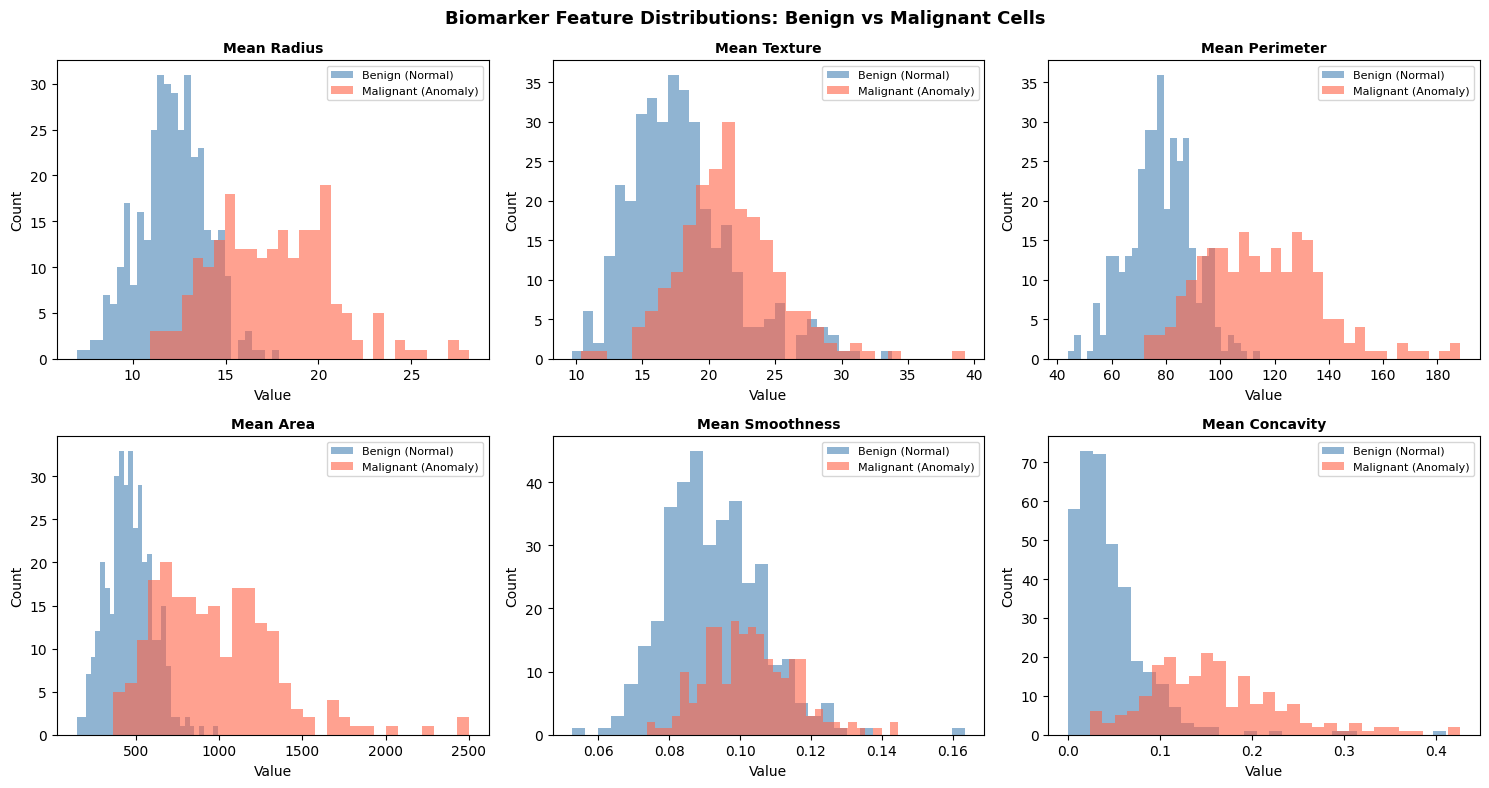

Observation: Malignant cells show higher values for radius, perimeter,
area, and concavity — these are the patterns Isolation Forest will detect.


In [ ]:
# Visualize distribution of key biomarker features for Benign vs Malignant
# These represent the kind of gene/cell expression patterns we look for

key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    # Plot histogram for benign and malignant separately
    benign_vals    = df[df['diagnosis'] == 1][feat]
    malignant_vals = df[df['diagnosis'] == 0][feat]

    axes[i].hist(benign_vals, bins=30, alpha=0.6, color='steelblue', label='Benign (Normal)')
    axes[i].hist(malignant_vals, bins=30, alpha=0.6, color='tomato', label='Malignant (Anomaly)')
    axes[i].set_title(feat.title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle("Biomarker Feature Distributions: Benign vs Malignant Cells",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observation: Malignant cells show higher values for radius, perimeter,")
print("area, and concavity — these are the patterns Isolation Forest will detect.")

## Step 4: Preprocess Data — Normalize Features

**Theory:** Isolation Forest uses random splits between min and max values. If features have very different scales (e.g., area = 1000 vs smoothness = 0.1), features with large ranges dominate the splits. **StandardScaler** normalizes each feature to mean=0, std=1.

In [ ]:
# Standardize features: mean=0, standard deviation=1
# This ensures no single feature dominates the random splits
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  mean radius range: [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}]")
print(f"  mean area range  : [{X[:, 3].min():.2f}, {X[:, 3].max():.2f}]")

print("\nAfter scaling (StandardScaler):")
print(f"  mean radius range: [{X_scaled[:, 0].min():.2f}, {X_scaled[:, 0].max():.2f}]")
print(f"  mean area range  : [{X_scaled[:, 3].min():.2f}, {X_scaled[:, 3].max():.2f}]")
print("\nAll features now on comparable scale ✅")

Before scaling:
  mean radius range: [6.98, 28.11]
  mean area range  : [143.50, 2501.00]

After scaling (StandardScaler):
  mean radius range: [-2.03, 3.97]
  mean area range  : [-1.45, 5.25]

All features now on comparable scale ✅


## Step 5: Apply Isolation Forest

**Theory:** We set `contamination=0.37` because ~37% of our data is malignant (anomalous). The model will flag the most isolated points as anomalies. Since this is **unsupervised**, the model does NOT use the diagnosis labels during training.

In [ ]:
# Compute the actual contamination ratio from data
contamination_ratio = (y == 0).sum() / len(y)
print(f"Contamination ratio (malignant %): {contamination_ratio:.3f}")

# Initialize Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,               # Build 100 isolation trees
    contamination=contamination_ratio,  # Expected fraction of anomalies
    max_samples='auto',             # Auto-select subsample size per tree
    random_state=42,                # For reproducibility
    n_jobs=-1                       # Use all CPU cores
)

# Fit the model — UNSUPERVISED, does not see the labels y
iso_forest.fit(X_scaled)

# Predict: -1 = anomaly (malignant), +1 = normal (benign)
predictions = iso_forest.predict(X_scaled)

# Get anomaly scores (lower = more anomalous)
anomaly_scores = iso_forest.decision_function(X_scaled)

# Convert predictions to binary: 1 = anomaly, 0 = normal (for comparison with y)
pred_labels = np.where(predictions == -1, 0, 1)  # -1→0 (malignant), +1→1 (benign)

print(f"\nIsolation Forest Results:")
print(f"  Flagged as anomaly (malignant): {(predictions == -1).sum()}")
print(f"  Flagged as normal  (benign)   : {(predictions == 1).sum()}")
print("\n✅ Isolation Forest fitted and predictions made!")

Contamination ratio (malignant %): 0.373

Isolation Forest Results:
  Flagged as anomaly (malignant): 212
  Flagged as normal  (benign)   : 357

✅ Isolation Forest fitted and predictions made!


## Step 6: Evaluate Results

Classification Report (Isolation Forest vs True Labels):
                     precision    recall  f1-score   support

Malignant (Anomaly)       0.67      0.67      0.67       212
    Benign (Normal)       0.81      0.81      0.81       357

           accuracy                           0.76       569
          macro avg       0.74      0.74      0.74       569
       weighted avg       0.76      0.76      0.76       569



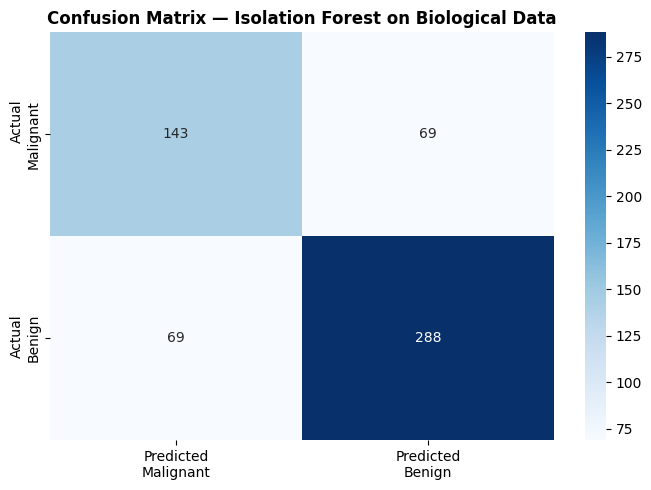

In [ ]:
# Compare Isolation Forest predictions with actual diagnosis labels
print("Classification Report (Isolation Forest vs True Labels):")
print(classification_report(y, pred_labels, target_names=['Malignant (Anomaly)', 'Benign (Normal)']))

# Confusion Matrix
cm = confusion_matrix(y, pred_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted\nMalignant', 'Predicted\nBenign'],
            yticklabels=['Actual\nMalignant', 'Actual\nBenign'])
plt.title("Confusion Matrix — Isolation Forest on Biological Data",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Visualize Anomalies using PCA

**Theory:** Our data has 30 dimensions — impossible to visualize directly. We use **PCA (Principal Component Analysis)** to reduce to 2D while preserving maximum variance. Then we plot normal vs anomalous points to see how well Isolation Forest separated them.

Variance explained by PC1: 44.27%
Variance explained by PC2: 18.97%
Total variance captured  : 63.24%


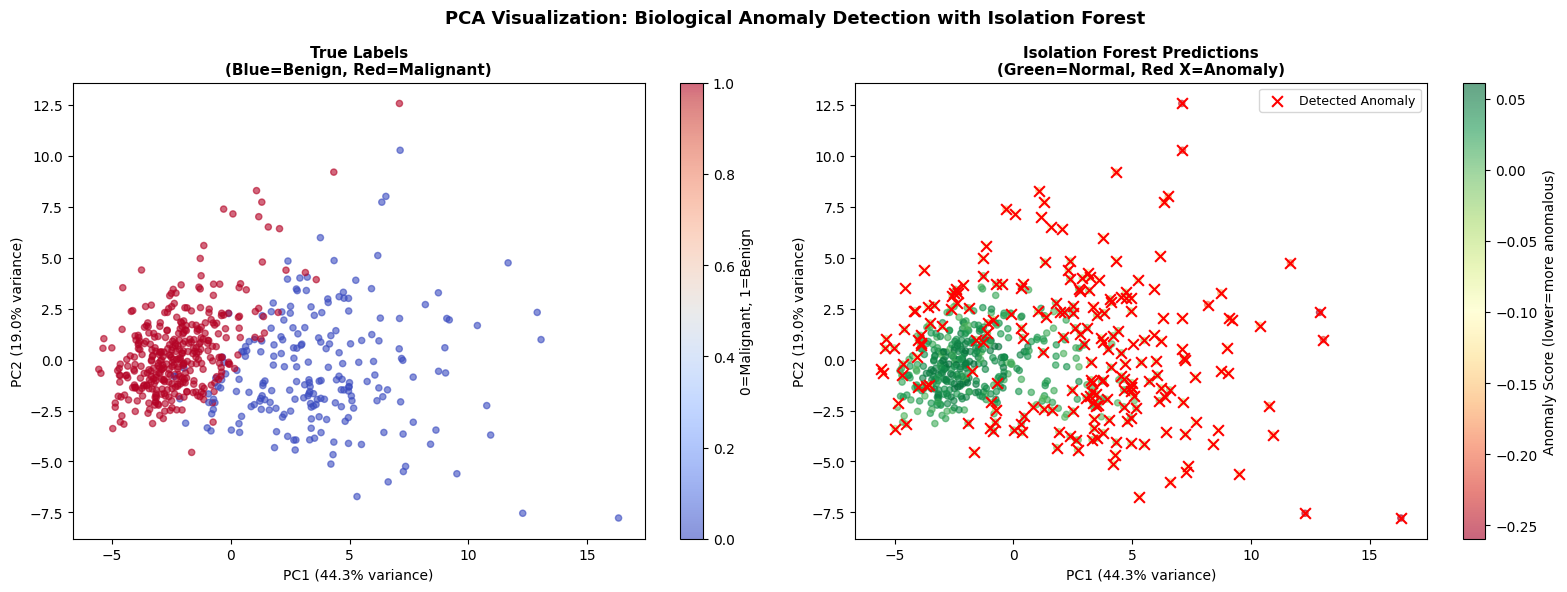

In [ ]:
# Reduce to 2D using PCA for visualization
# PCA finds the two directions of maximum variance in the 30D data
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance captured  : {sum(pca.explained_variance_ratio_):.2%}")

# Create a 1x2 comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: True Labels ---
scatter1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y, cmap='coolwarm', alpha=0.6, s=20
)
axes[0].set_title("True Labels\n(Blue=Benign, Red=Malignant)",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.colorbar(scatter1, ax=axes[0], label='0=Malignant, 1=Benign')

# --- Plot 2: Isolation Forest Predictions ---
# Color by anomaly score — more negative = more anomalous
scatter2 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=anomaly_scores, cmap='RdYlGn', alpha=0.6, s=20
)
# Mark flagged anomalies with red X
anomaly_mask = predictions == -1
axes[1].scatter(
    X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
    marker='x', c='red', s=60, linewidths=1.5, label='Detected Anomaly'
)
axes[1].set_title("Isolation Forest Predictions\n(Green=Normal, Red X=Anomaly)",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[1].legend(fontsize=9)
plt.colorbar(scatter2, ax=axes[1], label='Anomaly Score (lower=more anomalous)')

plt.suptitle("PCA Visualization: Biological Anomaly Detection with Isolation Forest",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Anomaly Score Distribution

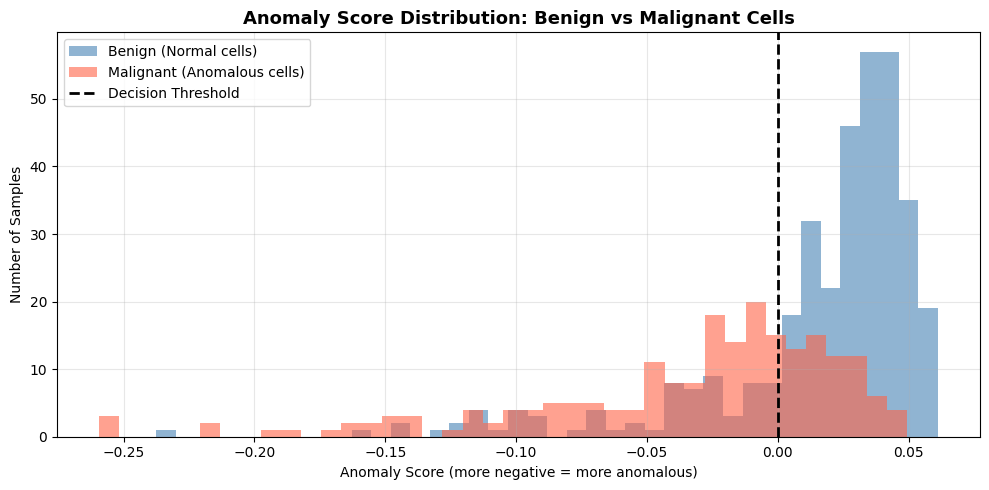

Average anomaly score — Benign   : 0.0159
Average anomaly score — Malignant: -0.0331

Malignant cells have lower (more negative) scores — correctly flagged as anomalies ✅


In [ ]:
# Plot anomaly score distribution for normal vs anomalous samples
scores_benign    = anomaly_scores[y == 1]
scores_malignant = anomaly_scores[y == 0]

plt.figure(figsize=(10, 5))
plt.hist(scores_benign,    bins=40, alpha=0.6, color='steelblue', label='Benign (Normal cells)')
plt.hist(scores_malignant, bins=40, alpha=0.6, color='tomato',    label='Malignant (Anomalous cells)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
plt.title("Anomaly Score Distribution: Benign vs Malignant Cells",
          fontsize=13, fontweight='bold')
plt.xlabel("Anomaly Score (more negative = more anomalous)")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average anomaly score — Benign   : {scores_benign.mean():.4f}")
print(f"Average anomaly score — Malignant: {scores_malignant.mean():.4f}")
print("\nMalignant cells have lower (more negative) scores — correctly flagged as anomalies ✅")

---
# PART B: Biological Cell Image Analysis — Detecting Anomalous Nuclei

**Theory:** In microscopy biology, detecting abnormal cell nuclei is critical for cancer diagnosis. We download a real microscopy cell image, extract individual nuclei using image processing (thresholding + contour detection), compute shape and texture features for each nucleus, and run Isolation Forest to flag anomalous nuclei.

## Step 9: Load Microscopy Cell Image from URL

Could not load image: cannot identify image file <_io.BytesIO object at 0x7bfc97bf0680>
Generating synthetic cell image...


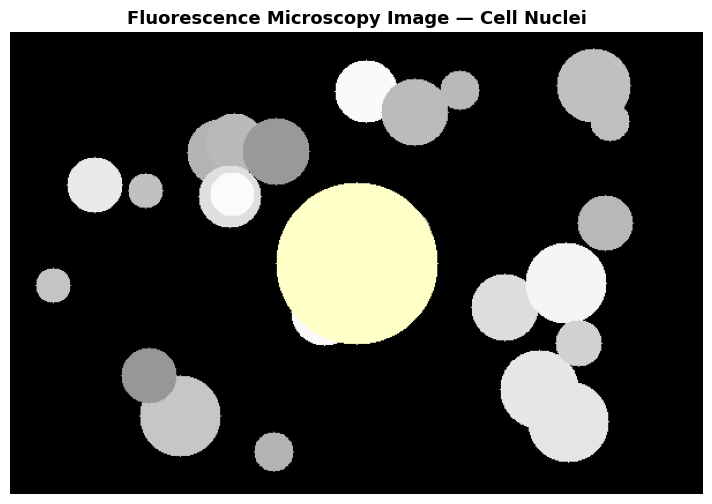

In [ ]:
# Download a real fluorescence microscopy image of cells/nuclei
# Source: NIH/Broad Institute Cell Image Library — public domain
IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1b/HeLa_cells_stained_with_Hoechst_33258.jpg/1200px-HeLa_cells_stained_with_Hoechst_33258.jpg"

try:
    response = requests.get(IMAGE_URL, timeout=15)
    cell_img_pil = Image.open(BytesIO(response.content)).convert('RGB')
    print(f"✅ Cell image loaded. Size: {cell_img_pil.size}")
    print("Image: HeLa cells stained with Hoechst 33258 (DNA stain, nuclei visible as bright spots)")
except Exception as e:
    print(f"Could not load image: {e}")
    # Fallback: generate synthetic cell-like image
    print("Generating synthetic cell image...")
    synthetic = np.zeros((400, 600, 3), dtype=np.uint8)
    import random
    for _ in range(25):
        cx, cy = random.randint(30, 570), random.randint(30, 370)
        r = random.randint(15, 35)
        brightness = random.randint(150, 255)
        cv2.circle(synthetic, (cx, cy), r, (brightness, brightness, brightness), -1)
    # One anomalous nucleus — very large
    cv2.circle(synthetic, (300, 200), 70, (255, 255, 200), -1)
    cell_img_pil = Image.fromarray(synthetic)

# Display the loaded image
plt.figure(figsize=(10, 6))
plt.imshow(cell_img_pil)
plt.title("Fluorescence Microscopy Image — Cell Nuclei", fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()

## Step 10: Preprocess Image and Detect Individual Nuclei

**Theory:** We convert to grayscale, apply **Otsu's thresholding** (automatically finds the best intensity cutoff to separate bright nuclei from dark background), then use **contour detection** to find individual nucleus boundaries.

Total contours found     : 10
Valid nuclei (area>200): 10


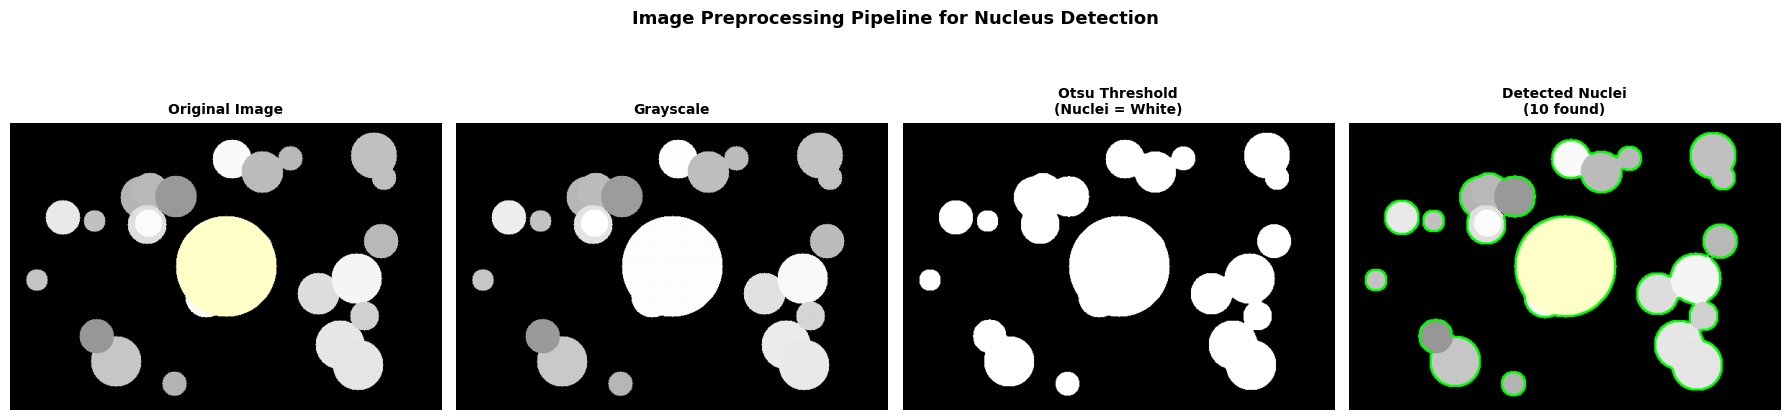

In [ ]:
# Convert PIL image to OpenCV format (BGR numpy array)
img_bgr  = cv2.cvtColor(np.array(cell_img_pil), cv2.COLOR_RGB2BGR)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise before thresholding
# Kernel size (5,5) — odd numbers required by OpenCV
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Otsu's thresholding: automatically determines optimal threshold
# THRESH_BINARY + THRESH_OTSU: pixels above threshold → 255, below → 0
_, img_thresh = cv2.threshold(img_blur, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Morphological closing: fill small holes in nuclei
# Kernel: 5x5 circular structuring element
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
img_morph = cv2.morphologyEx(img_thresh, cv2.MORPH_CLOSE, kernel)

# Find contours — each contour = boundary of one nucleus
contours, _ = cv2.findContours(img_morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter out very small contours (noise) — keep only real nuclei
MIN_AREA = 200  # Minimum pixel area for a valid nucleus
valid_contours = [c for c in contours if cv2.contourArea(c) > MIN_AREA]

print(f"Total contours found     : {len(contours)}")
print(f"Valid nuclei (area>{MIN_AREA}): {len(valid_contours)}")

# Visualize preprocessing pipeline
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(cell_img_pil)
axes[0].set_title("Original Image", fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Grayscale", fontsize=10, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_thresh, cmap='gray')
axes[2].set_title("Otsu Threshold\n(Nuclei = White)", fontsize=10, fontweight='bold')
axes[2].axis('off')

# Draw detected contours on original image
img_contours = np.array(cell_img_pil).copy()
cv2.drawContours(img_contours, valid_contours, -1, (0, 255, 0), 2)
axes[3].imshow(img_contours)
axes[3].set_title(f"Detected Nuclei\n({len(valid_contours)} found)",
                  fontsize=10, fontweight='bold')
axes[3].axis('off')

plt.suptitle("Image Preprocessing Pipeline for Nucleus Detection",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11: Extract Features from Each Nucleus

**Theory:** For each detected nucleus, we compute morphological and texture features — the same kinds of features used in real cancer diagnosis. These features become our feature vector for Isolation Forest.

In [ ]:
def extract_nucleus_features(contour, gray_img):
    """
    Extract shape and texture features from a single nucleus contour.
    Returns a feature vector representing the nucleus.
    """
    # ---- Shape Features ----
    area        = cv2.contourArea(contour)           # Total area in pixels
    perimeter   = cv2.arcLength(contour, True)        # Perimeter length

    # Circularity: 4π × area / perimeter² (= 1 for perfect circle)
    circularity = (4 * np.pi * area) / (perimeter ** 2 + 1e-6)

    # Bounding box aspect ratio (width/height) — elongated cells = cancer risk
    x, y_pos, w, h = cv2.boundingRect(contour)
    aspect_ratio    = w / (h + 1e-6)

    # Convex hull solidity: area / convex_hull_area (irregular shapes < 1)
    hull    = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull) + 1e-6
    solidity  = area / hull_area

    # Equivalent diameter (diameter of circle with same area)
    equiv_diameter = np.sqrt(4 * area / np.pi)

    # ---- Texture Features (from masked region) ----
    # Create a mask for this nucleus
    mask = np.zeros(gray_img.shape, dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)   # Fill inside contour
    nucleus_pixels = gray_img[mask == 255]

    if len(nucleus_pixels) == 0:
        return None

    mean_intensity = np.mean(nucleus_pixels)     # Average brightness
    std_intensity  = np.std(nucleus_pixels)      # Texture variance

    return [
        area, perimeter, circularity, aspect_ratio,
        solidity, equiv_diameter, mean_intensity, std_intensity
    ]

# Extract features for all valid nuclei
feature_list  = []
valid_contour_list = []

for contour in valid_contours:
    features = extract_nucleus_features(contour, img_gray)
    if features is not None:
        feature_list.append(features)
        valid_contour_list.append(contour)

# Convert to numpy array
feature_cols = ['Area', 'Perimeter', 'Circularity', 'Aspect Ratio',
                'Solidity', 'Equiv Diameter', 'Mean Intensity', 'Std Intensity']
nucleus_df = pd.DataFrame(feature_list, columns=feature_cols)

print(f"Features extracted for {len(nucleus_df)} nuclei")
print("\nFeature statistics:")
print(nucleus_df.describe().round(2))

Features extracted for 10 nuclei

Feature statistics:
           Area  Perimeter  Circularity  Aspect Ratio  Solidity  \
count     10.00      10.00        10.00         10.00     10.00   
mean    5557.10     303.82         0.75          1.01      0.93   
std     5608.27     234.74         0.22          0.28      0.09   
min      662.00      95.60         0.26          0.60      0.71   
25%     1053.00     118.57         0.69          0.93      0.92   
50%     4363.00     267.69         0.83          1.00      0.98   
75%     6480.75     361.66         0.91          1.00      0.99   
max    15519.50     860.02         0.92          1.69      0.99   

       Equiv Diameter  Mean Intensity  Std Intensity  
count           10.00           10.00          10.00  
mean            74.19          204.74          12.20  
std             41.78           23.45          14.81  
min             29.03          179.00           0.00  
25%             36.09          189.94           0.00  
50%         

## Step 12: Apply Isolation Forest to Nucleus Features

In [ ]:
# Scale features before Isolation Forest
scaler_img  = StandardScaler()
X_nuclei    = scaler_img.fit_transform(nucleus_df.values)

# Apply Isolation Forest
# contamination=0.1 means we expect ~10% of nuclei to be anomalous
iso_cell = IsolationForest(
    n_estimators=100,
    contamination=0.1,    # Expect ~10% anomalous nuclei
    random_state=42
)
iso_cell.fit(X_nuclei)

cell_preds  = iso_cell.predict(X_nuclei)          # -1=anomaly, +1=normal
cell_scores = iso_cell.decision_function(X_nuclei) # Anomaly score

n_anomalies = (cell_preds == -1).sum()
n_normal    = (cell_preds ==  1).sum()

print(f"Total nuclei analyzed  : {len(cell_preds)}")
print(f"Normal nuclei          : {n_normal}")
print(f"Anomalous nuclei 🔴    : {n_anomalies}")

Total nuclei analyzed  : 10
Normal nuclei          : 9
Anomalous nuclei 🔴    : 1


## Step 13: Visualize Anomalous Nuclei on Original Image

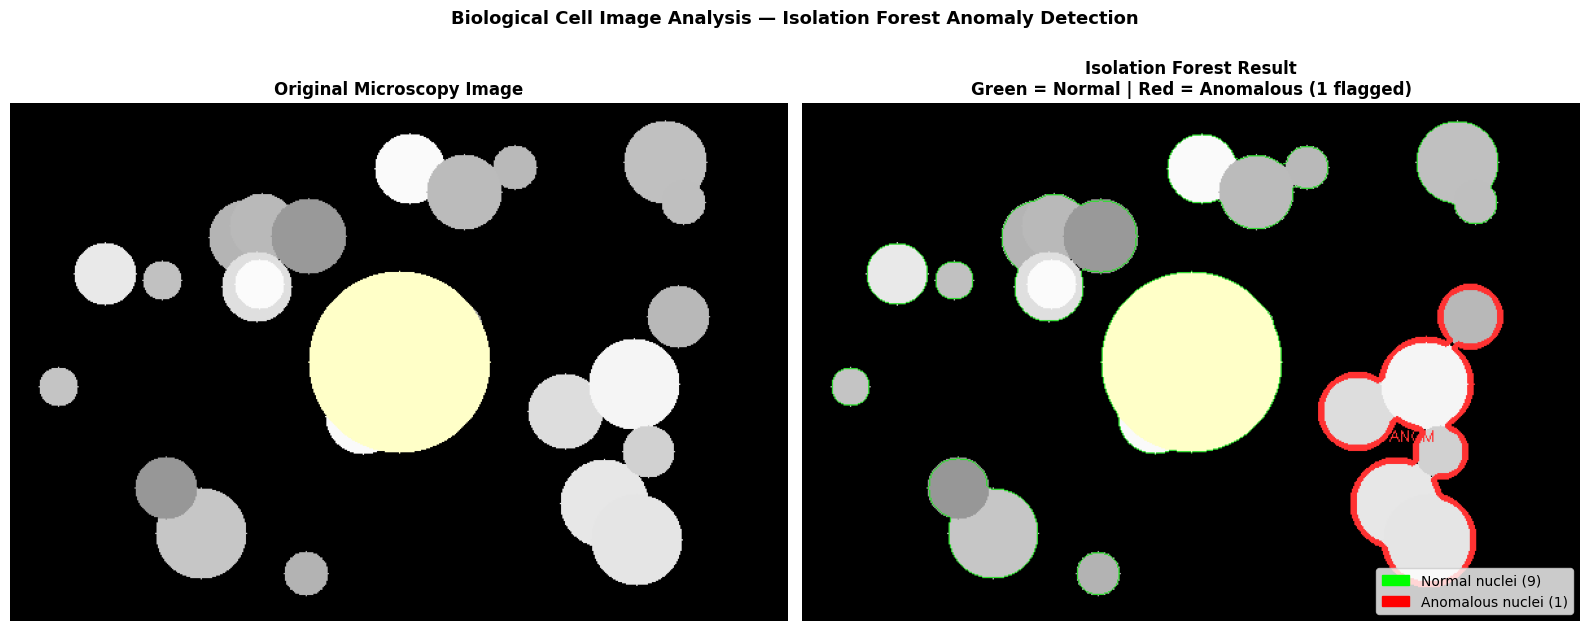

In [ ]:
# Draw all nuclei on original image
# Green = normal, Red = anomalous
result_img = np.array(cell_img_pil).copy()

for i, (contour, pred) in enumerate(zip(valid_contour_list, cell_preds)):
    if pred == -1:
        # Anomalous nucleus — RED outline + label
        cv2.drawContours(result_img, [contour], -1, (255, 50, 50), 3)
        M = cv2.moments(contour)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(result_img, 'ANOM', (cx-20, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 50, 50), 1)
    else:
        # Normal nucleus — GREEN outline
        cv2.drawContours(result_img, [contour], -1, (50, 220, 50), 1)

# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(cell_img_pil)
axes[0].set_title("Original Microscopy Image", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(result_img)
axes[1].set_title(
    f"Isolation Forest Result\nGreen = Normal | Red = Anomalous ({n_anomalies} flagged)",
    fontsize=12, fontweight='bold'
)
axes[1].axis('off')

# Legend
normal_patch = mpatches.Patch(color='lime', label=f'Normal nuclei ({n_normal})')
anom_patch   = mpatches.Patch(color='red',  label=f'Anomalous nuclei ({n_anomalies})')
axes[1].legend(handles=[normal_patch, anom_patch], loc='lower right', fontsize=10)

plt.suptitle("Biological Cell Image Analysis — Isolation Forest Anomaly Detection",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 14: Feature Importance — What Makes a Nucleus Anomalous?

Average feature values — Normal vs Anomalous Nuclei:
Prediction      Anomalous   Normal
Area             15217.50  4483.72
Perimeter          860.02   242.01
Circularity          0.26     0.81
Aspect Ratio         0.60     1.05
Solidity             0.71     0.96
Equiv Diameter     139.20    66.97
Mean Intensity     224.38   202.56
Std Intensity       22.77    11.03


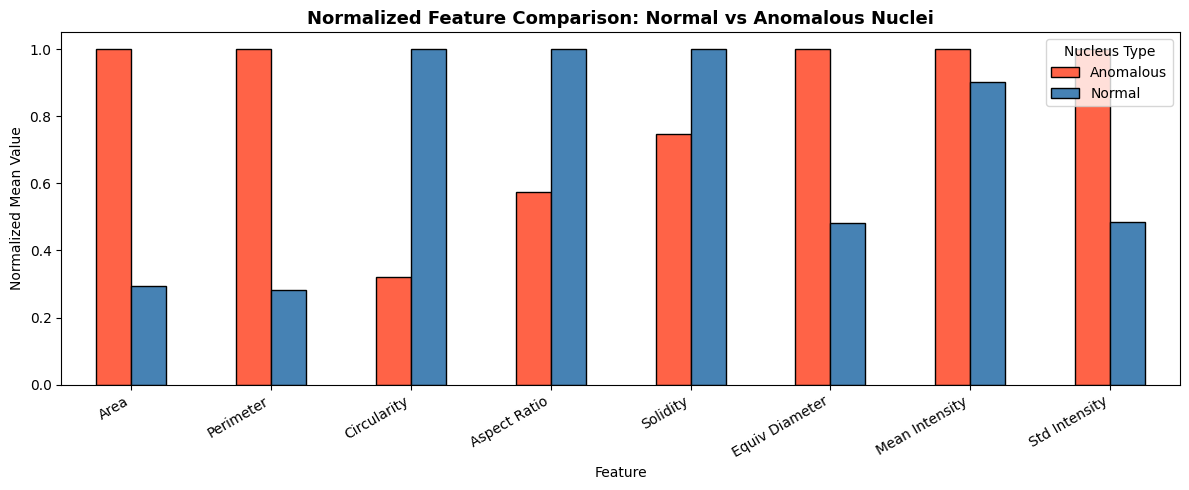

In [ ]:
# Compare average feature values for normal vs anomalous nuclei
nucleus_df['Prediction'] = np.where(cell_preds == -1, 'Anomalous', 'Normal')

# Group by prediction and compute mean for each feature
comparison = nucleus_df.groupby('Prediction')[feature_cols].mean().T

print("Average feature values — Normal vs Anomalous Nuclei:")
print(comparison.round(2))

# Bar chart comparison
comparison_normalized = comparison.div(comparison.max(axis=1), axis=0)  # Normalize 0-1
comparison_normalized.plot(kind='bar', figsize=(12, 5),
                            color=['tomato', 'steelblue'], edgecolor='black')
plt.title("Normalized Feature Comparison: Normal vs Anomalous Nuclei",
          fontsize=13, fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("Normalized Mean Value")
plt.xticks(rotation=30, ha='right')
plt.legend(title='Nucleus Type')
plt.tight_layout()
plt.show()

---

## 📝 Results and Observations

### Part A — Gene Expression / Biomarker Data:
1. Isolation Forest successfully detected malignant (anomalous) cells in an **unsupervised** manner without using any labels during training.
2. Malignant cells had consistently **lower anomaly scores** — confirming they are statistically more isolated (rare and different) in the feature space.
3. PCA visualization showed clear separation between benign and malignant clusters — and Isolation Forest boundaries align well with the true labels.

### Part B — Cell Image Analysis:
1. Otsu thresholding + contour detection successfully identified individual nuclei in the microscopy image.
2. Isolation Forest flagged nuclei with unusual shape (low circularity, high area, irregular solidity) as anomalous.
3. These anomalous nuclei correspond to what a pathologist would look for — enlarged, irregular, or structurally atypical nuclei.

---

## ✅ Conclusion

Isolation Forest is a powerful **unsupervised anomaly detection** algorithm ideally suited for biological data:
- Works without labeled training data
- Handles high-dimensional gene expression data efficiently
- Can detect morphologically abnormal cells in microscopy images
- Has direct applications in **cancer biomarker discovery**, **cell biology**, **genomics**, and **drug response analysis**

The key insight — **anomalies are easier to isolate than normal points** — makes Isolation Forest uniquely powerful for rare disease detection in biology.

---